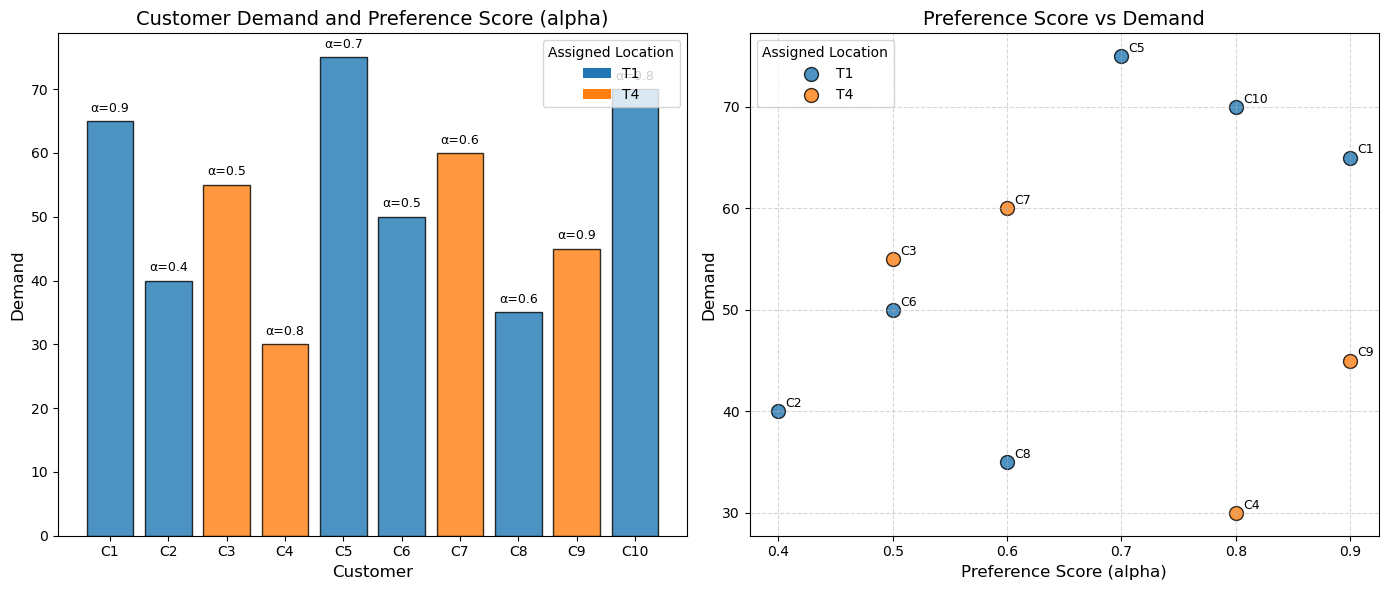

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Construct the dataset
data = {
    'Customer': ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10'],
    'Assigned Location': ['T1', 'T1', 'T4', 'T4', 'T1', 'T1', 'T4', 'T1', 'T4', 'T1'],
    'Preference Score (alpha)': [0.9, 0.4, 0.5, 0.8, 0.7, 0.5, 0.6, 0.6, 0.9, 0.8],
    'Demand': [65, 40, 55, 30, 75, 50, 60, 35, 45, 70]
}
df = pd.DataFrame(data)

# Define color mapping
colors = {'T1': '#1f77b4', 'T4': '#ff7f0e'}
df['color'] = df['Assigned Location'].map(colors)

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---------- Left plot: Demand bar chart (with alpha annotation) ----------
bars = ax1.bar(df['Customer'], df['Demand'], color=df['color'], edgecolor='black', alpha=0.8)
ax1.set_xlabel('Customer', fontsize=12)
ax1.set_ylabel('Demand', fontsize=12)
ax1.set_title('Customer Demand and Preference Score (alpha)', fontsize=14)

# Annotate alpha values above bars
for bar, alpha in zip(bars, df['Preference Score (alpha)']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'α={alpha:.1f}', ha='center', va='bottom', fontsize=9)

# Add T1/T4 legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors['T1'], label='T1'),
                   Patch(facecolor=colors['T4'], label='T4')]
ax1.legend(handles=legend_elements, title='Assigned Location', loc='upper right')

# ---------- Right plot: alpha vs demand scatter plot ----------
for loc in ['T1', 'T4']:
    subset = df[df['Assigned Location'] == loc]
    ax2.scatter(subset['Preference Score (alpha)'], subset['Demand'],
                s=100, c=colors[loc], label=loc, edgecolor='black', alpha=0.8)
    # Add customer labels
    for _, row in subset.iterrows():
        ax2.annotate(row['Customer'], (row['Preference Score (alpha)'], row['Demand']),
                     xytext=(5, 3), textcoords='offset points', fontsize=9)

ax2.set_xlabel('Preference Score (alpha)', fontsize=12)
ax2.set_ylabel('Demand', fontsize=12)
ax2.set_title('Preference Score vs Demand', fontsize=14)
ax2.legend(title='Assigned Location')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

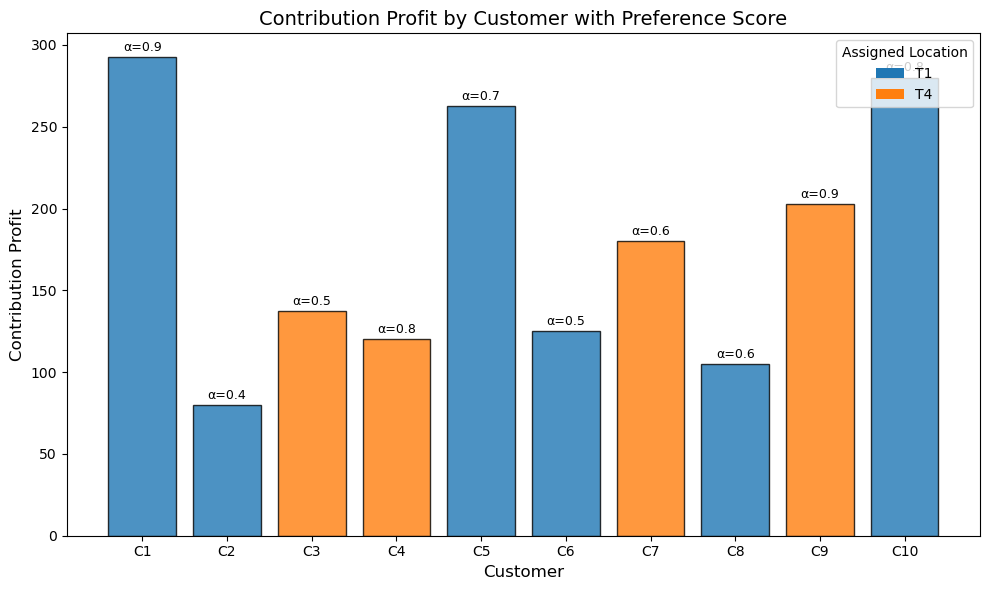

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Construct the dataset with contribution profit
data = {
    'Customer': ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10'],
    'Assigned Location': ['T1', 'T1', 'T4', 'T4', 'T1', 'T1', 'T4', 'T1', 'T4', 'T1'],
    'Preference Score (alpha)': [0.9, 0.4, 0.5, 0.8, 0.7, 0.5, 0.6, 0.6, 0.9, 0.8],
    'Contribution Profit': [292.5, 80.0, 137.5, 120.0, 262.5, 125.0, 180.0, 105.0, 202.5, 280.0]
}
df = pd.DataFrame(data)

# Color mapping for locations
colors = {'T1': '#1f77b4', 'T4': '#ff7f0e'}
df['color'] = df['Assigned Location'].map(colors)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df['Customer'], df['Contribution Profit'], 
              color=df['color'], edgecolor='black', alpha=0.8)

# Annotate preference score (alpha) above each bar
for bar, alpha in zip(bars, df['Preference Score (alpha)']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'α={alpha:.1f}', ha='center', va='bottom', fontsize=9)

# Labels and title
ax.set_xlabel('Customer', fontsize=12)
ax.set_ylabel('Contribution Profit', fontsize=12)
ax.set_title('Contribution Profit by Customer with Preference Score', fontsize=14)

# Legend for T1 / T4
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors['T1'], label='T1'),
                   Patch(facecolor=colors['T4'], label='T4')]
ax.legend(handles=legend_elements, title='Assigned Location', loc='upper right')

plt.tight_layout()
plt.show()

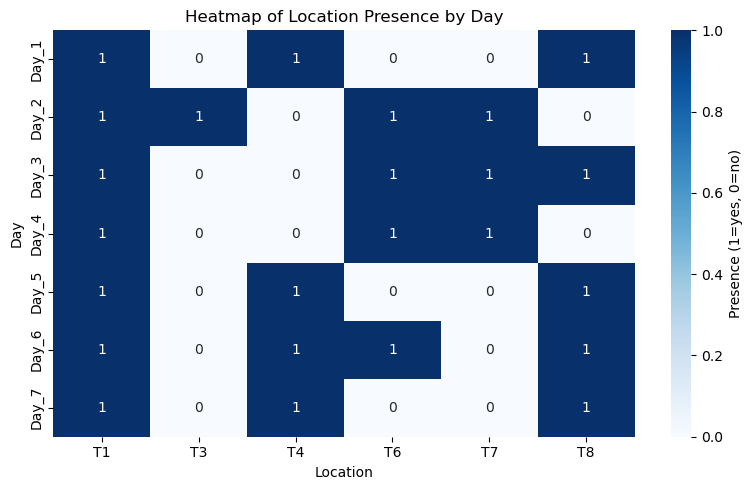

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Input data as dictionary
data = {
    'Day': ['Day_1', 'Day_1', 'Day_1', 'Day_2', 'Day_2', 'Day_2', 'Day_2', 
            'Day_3', 'Day_3', 'Day_3', 'Day_3', 'Day_4', 'Day_4', 'Day_4', 
            'Day_5', 'Day_5', 'Day_5', 'Day_6', 'Day_6', 'Day_6', 'Day_6', 
            'Day_7', 'Day_7', 'Day_7'],
    'Location': ['T1', 'T4', 'T8', 'T1', 'T3', 'T6', 'T7', 'T1', 'T6', 'T7', 'T8', 
                 'T1', 'T6', 'T7', 'T1', 'T4', 'T8', 'T1', 'T4', 'T6', 'T8', 
                 'T1', 'T4', 'T8'],
    'Truck_Type': ['Large', 'Small', 'Small', 'Medium', 'Small', 'Small', 'Small', 
                   'Medium', 'Small', 'Small', 'Small', 'Medium', 'Small', 'Medium', 
                   'Large', 'Small', 'Medium', 'Small', 'Small', 'Small', 'Medium', 
                   'Large', 'Small', 'Medium'],
    'Customers_Served': [4, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 4, 2, 4, 3, 3, 4, 2, 3, 1, 4, 3, 3, 4],
    'Daily_Profit_Contribution': [636.0, 215.0, 316.5, 436.5, 239.0, 254.5, 319.0, 
                                  353.5, 319.0, 286.0, 293.0, 483.0, 280.5, 494.5, 
                                  461.0, 280.5, 494.0, 304.0, 233.5, 216.0, 456.5, 
                                  570.5, 312.0, 476.0]
}
df = pd.DataFrame(data)

# Create a pivot table: rows = Day, columns = Location, values = 1 if present else 0
pivot = pd.crosstab(df['Day'], df['Location'])

# Convert to binary presence (already 0/1 from crosstab)
# Optionally, set NaN to 0 (crosstab gives 0 for absence by default)
pivot = pivot.astype(int)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Presence (1=yes, 0=no)'})
plt.title('Heatmap of Location Presence by Day')
plt.xlabel('Location')
plt.ylabel('Day')
plt.tight_layout()
plt.show()

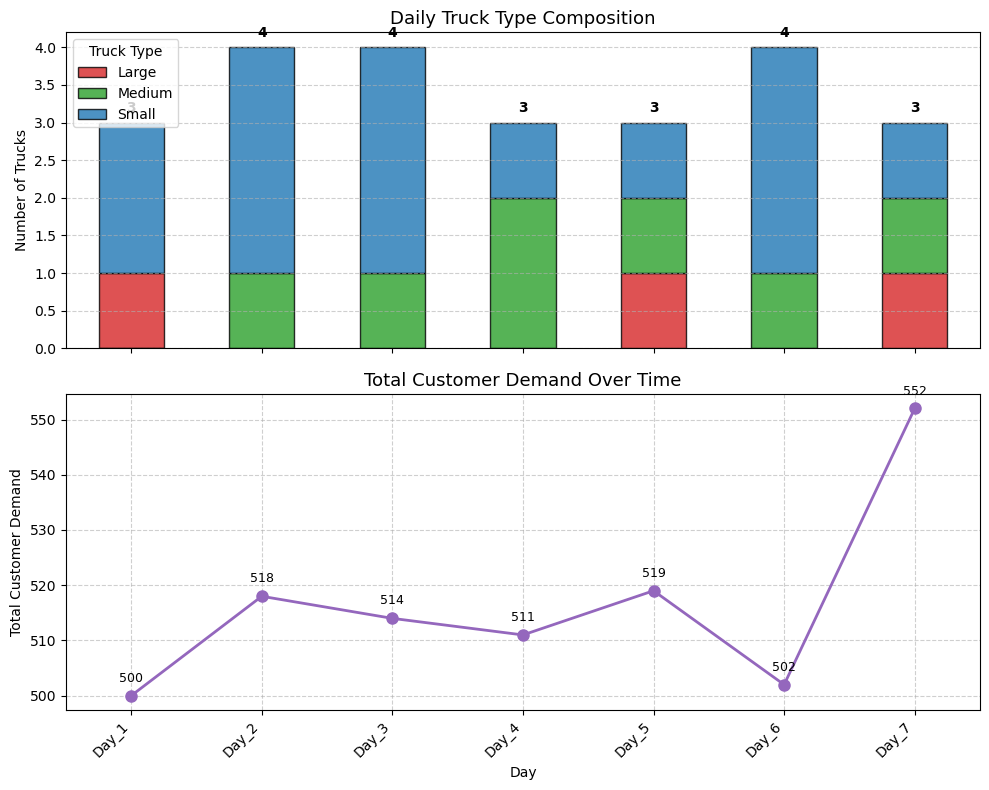

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# 1. Customer demand data (transposed to days as rows)
# ------------------------------
demand_data = {
    'Customer': ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10'],
    'Day_1': [62, 46, 48, 26, 78, 56, 49, 31, 38, 66],
    'Day_2': [77, 42, 48, 28, 61, 46, 70, 42, 40, 64],
    'Day_3': [71, 43, 51, 28, 78, 42, 54, 39, 37, 71],
    'Day_4': [68, 32, 56, 29, 65, 54, 64, 41, 42, 60],
    'Day_5': [56, 48, 54, 33, 62, 49, 55, 41, 43, 78],
    'Day_6': [56, 45, 50, 26, 88, 42, 60, 36, 41, 58],
    'Day_7': [54, 35, 57, 30, 89, 50, 61, 41, 51, 84]
}
df_demand = pd.DataFrame(demand_data)
df_demand.set_index('Customer', inplace=True)

# Calculate total demand per day
total_demand_per_day = df_demand.sum(axis=0)  # Sum across customers for each day
days = total_demand_per_day.index.tolist()
total_demand = total_demand_per_day.values

# ------------------------------
# 2. Truck type composition data (already in day-indexed format)
# ------------------------------
truck_data = {
    'Day': ['Day_1', 'Day_2', 'Day_3', 'Day_4', 'Day_5', 'Day_6', 'Day_7'],
    'Large': [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0],
    'Medium': [0.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0],
    'Small': [2.0, 3.0, 3.0, 1.0, 1.0, 3.0, 1.0]
}
df_trucks = pd.DataFrame(truck_data)
df_trucks.set_index('Day', inplace=True)

# Ensure both dataframes align on the same day order
df_trucks = df_trucks.reindex(days)

# ------------------------------
# 3. Visualization: Two subplots (stacked bar for truck mix, line for total demand)
# ------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [1, 1]})

# ---- Top plot: Stacked bar chart of truck types ----
truck_colors = {'Large': '#d62728', 'Medium': '#2ca02c', 'Small': '#1f77b4'}
df_trucks.plot(kind='bar', stacked=True, ax=ax1, color=[truck_colors[col] for col in df_trucks.columns],
               edgecolor='black', alpha=0.8)
ax1.set_ylabel('Number of Trucks')
ax1.set_title('Daily Truck Type Composition', fontsize=13)
ax1.legend(title='Truck Type', loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Add total truck count on top of each stacked bar
for i, (idx, row) in enumerate(df_trucks.iterrows()):
    total_trucks = row.sum()
    ax1.text(i, total_trucks + 0.1, f'{int(total_trucks)}', ha='center', va='bottom', fontweight='bold')

# ---- Bottom plot: Line chart of total demand ----
ax2.plot(days, total_demand, marker='o', linestyle='-', linewidth=2, markersize=8, color='#9467bd')
ax2.set_ylabel('Total Customer Demand')
ax2.set_xlabel('Day')
ax2.set_title('Total Customer Demand Over Time', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.6)

# Annotate demand values on points
for x, y in zip(days, total_demand):
    ax2.annotate(f'{y}', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

# Improve x-axis labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

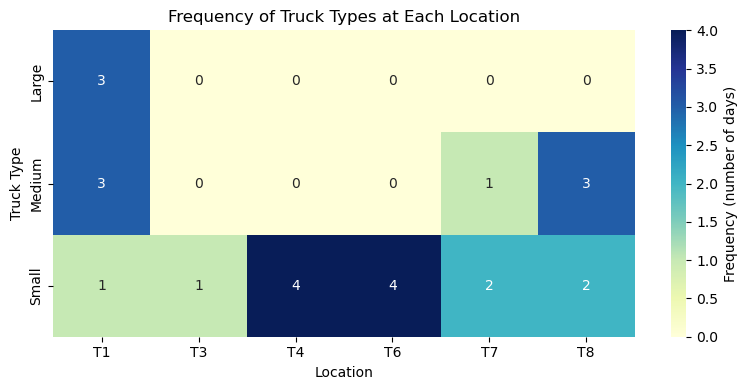

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Input data
data = {
    'Day': ['Day_1', 'Day_1', 'Day_1', 'Day_2', 'Day_2', 'Day_2', 'Day_2', 
            'Day_3', 'Day_3', 'Day_3', 'Day_3', 'Day_4', 'Day_4', 'Day_4', 
            'Day_5', 'Day_5', 'Day_5', 'Day_6', 'Day_6', 'Day_6', 'Day_6', 
            'Day_7', 'Day_7', 'Day_7'],
    'Location': ['T1', 'T4', 'T8', 'T1', 'T3', 'T6', 'T7', 'T1', 'T6', 'T7', 'T8', 
                 'T1', 'T6', 'T7', 'T1', 'T4', 'T8', 'T1', 'T4', 'T6', 'T8', 
                 'T1', 'T4', 'T8'],
    'Truck_Type': ['Large', 'Small', 'Small', 'Medium', 'Small', 'Small', 'Small', 
                   'Medium', 'Small', 'Small', 'Small', 'Medium', 'Small', 'Medium', 
                   'Large', 'Small', 'Medium', 'Small', 'Small', 'Small', 'Medium', 
                   'Large', 'Small', 'Medium'],
    'Customers_Served': [4, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 4, 2, 4, 3, 3, 4, 2, 3, 1, 4, 3, 3, 4],
    'Daily_Profit_Contribution': [636.0, 215.0, 316.5, 436.5, 239.0, 254.5, 319.0, 
                                  353.5, 319.0, 286.0, 293.0, 483.0, 280.5, 494.5, 
                                  461.0, 280.5, 494.0, 304.0, 233.5, 216.0, 456.5, 
                                  570.5, 312.0, 476.0]
}
df = pd.DataFrame(data)

# Create frequency table: Truck_Type (rows) vs Location (columns)
freq_table = pd.crosstab(df['Truck_Type'], df['Location'])

# Plot heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(freq_table, annot=True, fmt='d', cmap='YlGnBu', 
            cbar_kws={'label': 'Frequency (number of days)'})
plt.title('Frequency of Truck Types at Each Location')
plt.xlabel('Location')
plt.ylabel('Truck Type')
plt.tight_layout()
plt.show()

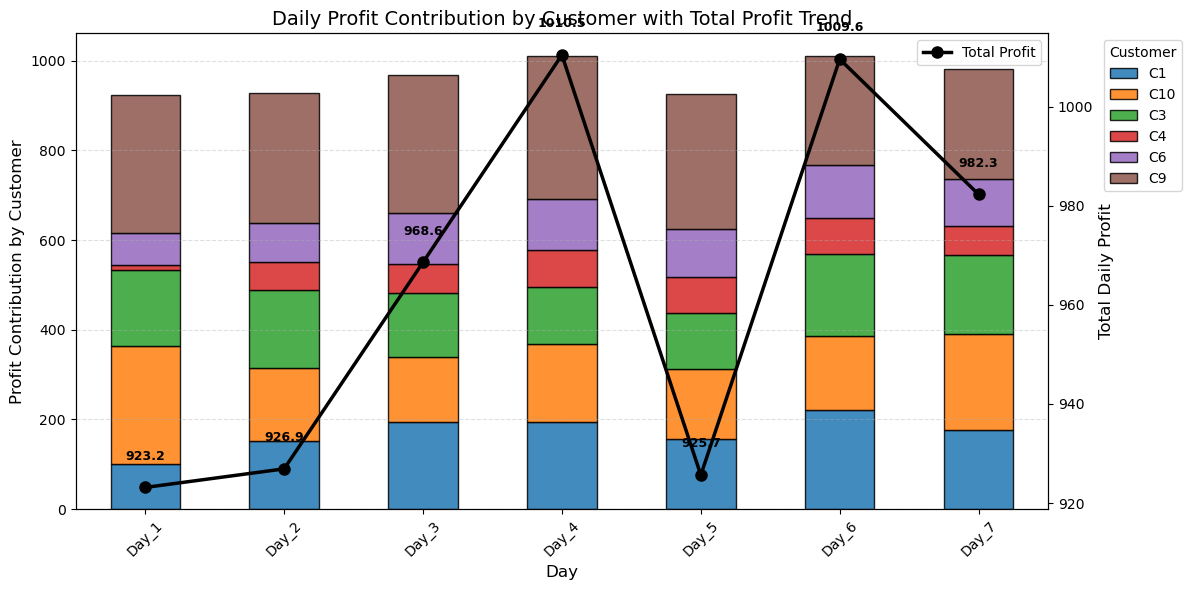

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. Construct the dataset
# ------------------------------
data = {
    'Day': ['Day_1', 'Day_1', 'Day_1', 'Day_1', 'Day_1', 'Day_1',
            'Day_2', 'Day_2', 'Day_2', 'Day_2', 'Day_2', 'Day_2',
            'Day_3', 'Day_3', 'Day_3', 'Day_3', 'Day_3', 'Day_3',
            'Day_4', 'Day_4', 'Day_4', 'Day_4', 'Day_4', 'Day_4',
            'Day_5', 'Day_5', 'Day_5', 'Day_5', 'Day_5', 'Day_5',
            'Day_6', 'Day_6', 'Day_6', 'Day_6', 'Day_6', 'Day_6',
            'Day_7', 'Day_7', 'Day_7', 'Day_7', 'Day_7', 'Day_7'],
    'Location': ['T2', 'T2', 'T3', 'T3', 'T3', 'T3',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8'],
    'Truck_Type': ['Small', 'Small', 'Small', 'Small', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small'],
    'Customer': ['C3', 'C9', 'C1', 'C4', 'C6', 'C10',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4'],
    'Preference_Alpha': [0.5, 0.76, 0.33, 0.05, 0.5, 0.69,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29],
    'Actual_Demand': [68, 81, 61, 50, 28, 76,
                      70, 28, 76, 64, 52, 42,
                      57, 36, 81, 57, 67, 45,
                      51, 36, 84, 68, 67, 57,
                      50, 34, 79, 61, 54, 56,
                      73, 37, 64, 65, 76, 56,
                      70, 33, 65, 84, 61, 45],
    'Profit_Contribution': [170.0, 307.8, 100.65, 12.5, 70.0, 262.2,
                            175.0, 88.2, 288.8, 163.2, 150.8, 60.9,
                            142.5, 113.4, 307.8, 145.35, 194.3, 65.25,
                            127.5, 113.4, 319.2, 173.4, 194.3, 82.65,
                            125.0, 107.1, 300.2, 155.55, 156.6, 81.2,
                            182.5, 116.55, 243.2, 165.75, 220.4, 81.2,
                            175.0, 103.95, 247.0, 214.2, 176.9, 65.25]
}

df = pd.DataFrame(data)

# 2. Create pivot table: daily profit contribution by customer
pivot = df.pivot_table(index='Day', columns='Customer', values='Profit_Contribution', aggfunc='sum')
# Sort by day (natural order)
days_order = [f'Day_{i}' for i in range(1, 8)]
pivot = pivot.reindex(days_order)

# Calculate daily total profit
daily_total = pivot.sum(axis=1)

# 3. Plot stacked bar chart + total profit line
fig, ax = plt.subplots(figsize=(12, 6))

# Use tab10 colormap to ensure consistent customer colors
colors = plt.cm.tab10.colors[:len(pivot.columns)]
pivot.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', alpha=0.85)

# Add total profit line (secondary axis)
ax2 = ax.twinx()
ax2.plot(range(len(daily_total)), daily_total.values, color='black', marker='o', linewidth=2.5, 
         markersize=8, label='Total Profit')
ax2.set_ylabel('Total Daily Profit', fontsize=12)
ax2.legend(loc='upper right')

# Annotate total profit values
for i, val in enumerate(daily_total.values):
    ax2.text(i, val + 5, f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Primary axis settings
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Profit Contribution by Customer', fontsize=12)
ax.set_title('Daily Profit Contribution by Customer with Total Profit Trend', fontsize=14)
ax.legend(title='Customer', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(pivot.index, rotation=45)

# Grid lines
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

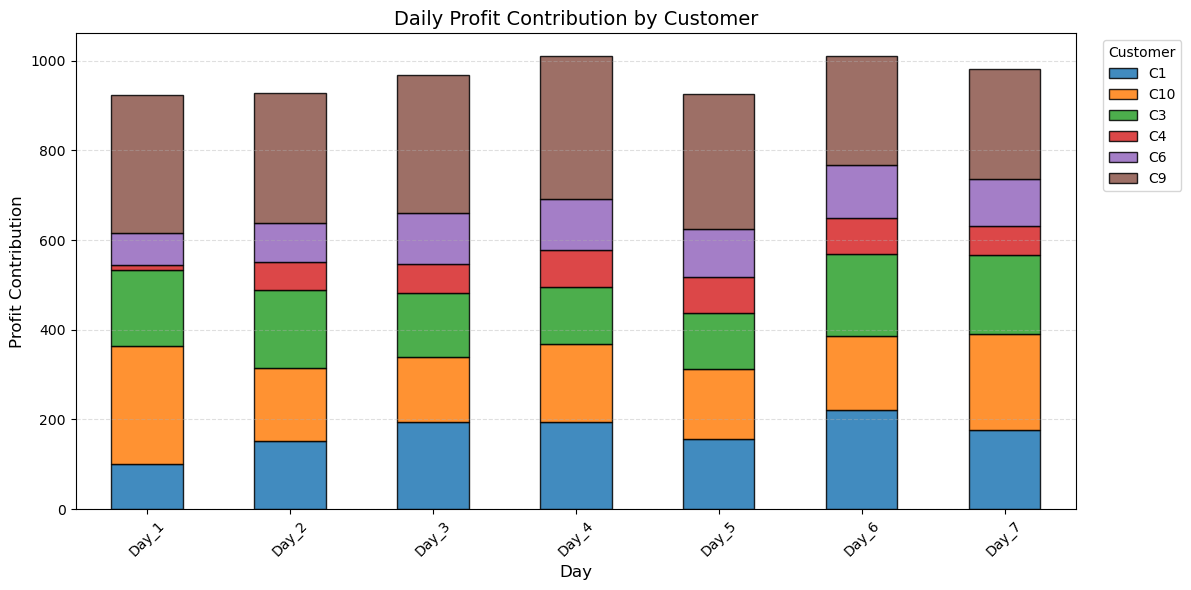

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 1. Construct the dataset
# ------------------------------
data = {
    'Day': ['Day_1', 'Day_1', 'Day_1', 'Day_1', 'Day_1', 'Day_1',
            'Day_2', 'Day_2', 'Day_2', 'Day_2', 'Day_2', 'Day_2',
            'Day_3', 'Day_3', 'Day_3', 'Day_3', 'Day_3', 'Day_3',
            'Day_4', 'Day_4', 'Day_4', 'Day_4', 'Day_4', 'Day_4',
            'Day_5', 'Day_5', 'Day_5', 'Day_5', 'Day_5', 'Day_5',
            'Day_6', 'Day_6', 'Day_6', 'Day_6', 'Day_6', 'Day_6',
            'Day_7', 'Day_7', 'Day_7', 'Day_7', 'Day_7', 'Day_7'],
    'Location': ['T2', 'T2', 'T3', 'T3', 'T3', 'T3',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8'],
    'Truck_Type': ['Small', 'Small', 'Small', 'Small', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small'],
    'Customer': ['C3', 'C9', 'C1', 'C4', 'C6', 'C10',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4'],
    'Preference_Alpha': [0.5, 0.76, 0.33, 0.05, 0.5, 0.69,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29],
    'Actual_Demand': [68, 81, 61, 50, 28, 76,
                      70, 28, 76, 64, 52, 42,
                      57, 36, 81, 57, 67, 45,
                      51, 36, 84, 68, 67, 57,
                      50, 34, 79, 61, 54, 56,
                      73, 37, 64, 65, 76, 56,
                      70, 33, 65, 84, 61, 45],
    'Profit_Contribution': [170.0, 307.8, 100.65, 12.5, 70.0, 262.2,
                            175.0, 88.2, 288.8, 163.2, 150.8, 60.9,
                            142.5, 113.4, 307.8, 145.35, 194.3, 65.25,
                            127.5, 113.4, 319.2, 173.4, 194.3, 82.65,
                            125.0, 107.1, 300.2, 155.55, 156.6, 81.2,
                            182.5, 116.55, 243.2, 165.75, 220.4, 81.2,
                            175.0, 103.95, 247.0, 214.2, 176.9, 65.25]
}

df = pd.DataFrame(data)

# ------------------------------
# 2. Create pivot table: daily profit contribution by customer
# ------------------------------
pivot = df.pivot_table(index='Day', columns='Customer', values='Profit_Contribution', aggfunc='sum')

# Arrange in natural day order
days_order = [f'Day_{i}' for i in range(1, 8)]
pivot = pivot.reindex(days_order)

# ------------------------------
# 3. Plot stacked bar chart
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Use tab10 colors to ensure distinct customer colors
colors = plt.cm.tab10.colors[:len(pivot.columns)]
pivot.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', alpha=0.85)

ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Profit Contribution', fontsize=12)
ax.set_title('Daily Profit Contribution by Customer', fontsize=14)
ax.legend(title='Customer', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(pivot.index, rotation=45)

# Add grid lines for easy value reading
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

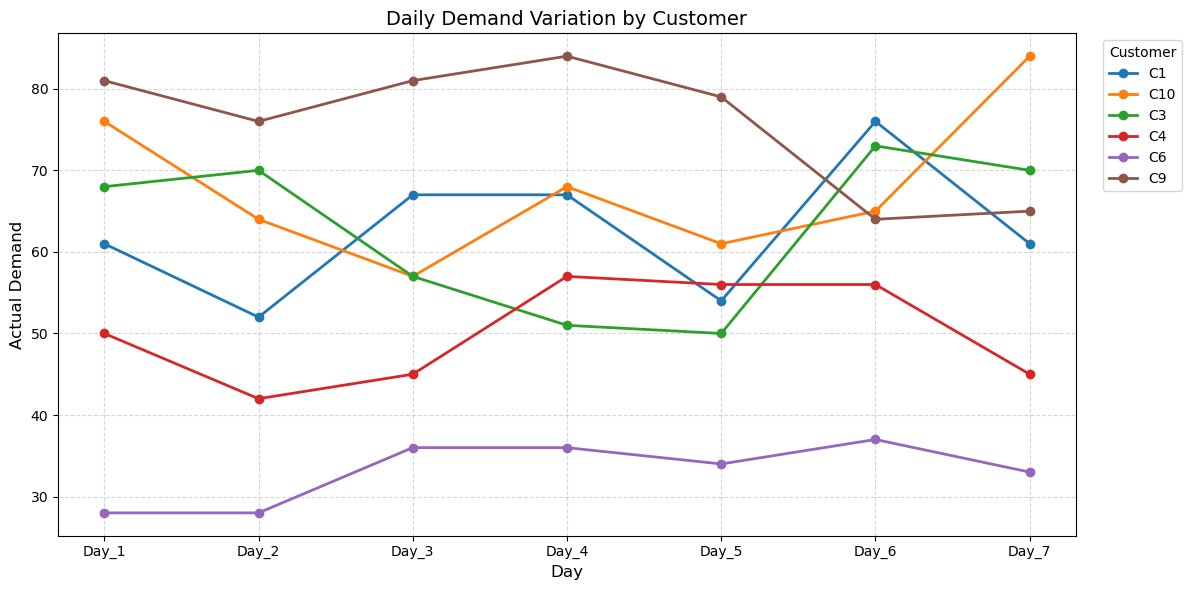

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 1. Construct the dataset
# ------------------------------
data = {
    'Day': ['Day_1', 'Day_1', 'Day_1', 'Day_1', 'Day_1', 'Day_1',
            'Day_2', 'Day_2', 'Day_2', 'Day_2', 'Day_2', 'Day_2',
            'Day_3', 'Day_3', 'Day_3', 'Day_3', 'Day_3', 'Day_3',
            'Day_4', 'Day_4', 'Day_4', 'Day_4', 'Day_4', 'Day_4',
            'Day_5', 'Day_5', 'Day_5', 'Day_5', 'Day_5', 'Day_5',
            'Day_6', 'Day_6', 'Day_6', 'Day_6', 'Day_6', 'Day_6',
            'Day_7', 'Day_7', 'Day_7', 'Day_7', 'Day_7', 'Day_7'],
    'Location': ['T2', 'T2', 'T3', 'T3', 'T3', 'T3',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8',
                 'T2', 'T2', 'T2', 'T2', 'T8', 'T8'],
    'Truck_Type': ['Small', 'Small', 'Small', 'Small', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small',
                   'Medium', 'Medium', 'Medium', 'Medium', 'Small', 'Small'],
    'Customer': ['C3', 'C9', 'C1', 'C4', 'C6', 'C10',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4',
                 'C3', 'C6', 'C9', 'C10', 'C1', 'C4'],
    'Preference_Alpha': [0.5, 0.76, 0.33, 0.05, 0.5, 0.69,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29,
                         0.5, 0.63, 0.76, 0.51, 0.58, 0.29],
    'Actual_Demand': [68, 81, 61, 50, 28, 76,
                      70, 28, 76, 64, 52, 42,
                      57, 36, 81, 57, 67, 45,
                      51, 36, 84, 68, 67, 57,
                      50, 34, 79, 61, 54, 56,
                      73, 37, 64, 65, 76, 56,
                      70, 33, 65, 84, 61, 45],
    'Profit_Contribution': [170.0, 307.8, 100.65, 12.5, 70.0, 262.2,
                            175.0, 88.2, 288.8, 163.2, 150.8, 60.9,
                            142.5, 113.4, 307.8, 145.35, 194.3, 65.25,
                            127.5, 113.4, 319.2, 173.4, 194.3, 82.65,
                            125.0, 107.1, 300.2, 155.55, 156.6, 81.2,
                            182.5, 116.55, 243.2, 165.75, 220.4, 81.2,
                            175.0, 103.95, 247.0, 214.2, 176.9, 65.25]
}
df = pd.DataFrame(data)

# ------------------------------
# 2. Prepare data for plotting
# ------------------------------
# Ensure days are ordered naturally
df['Day_Num'] = df['Day'].str.extract(r'(\d+)').astype(int)
df = df.sort_values('Day_Num')

# Create a pivot table: rows=Day, columns=Customer, values=Actual_Demand
pivot = df.pivot_table(index='Day', columns='Customer', values='Actual_Demand', aggfunc='sum')
# Reindex to guarantee day order
days_order = [f'Day_{i}' for i in range(1, 8)]
pivot = pivot.reindex(days_order)

# ------------------------------
# 3. Plot line chart for each customer
# ------------------------------
plt.figure(figsize=(12, 6))
for customer in pivot.columns:
    plt.plot(pivot.index, pivot[customer], marker='o', linewidth=2, label=customer)

plt.xlabel('Day', fontsize=12)
plt.ylabel('Actual Demand', fontsize=12)
plt.title('Daily Demand Variation by Customer', fontsize=14)
plt.legend(title='Customer', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

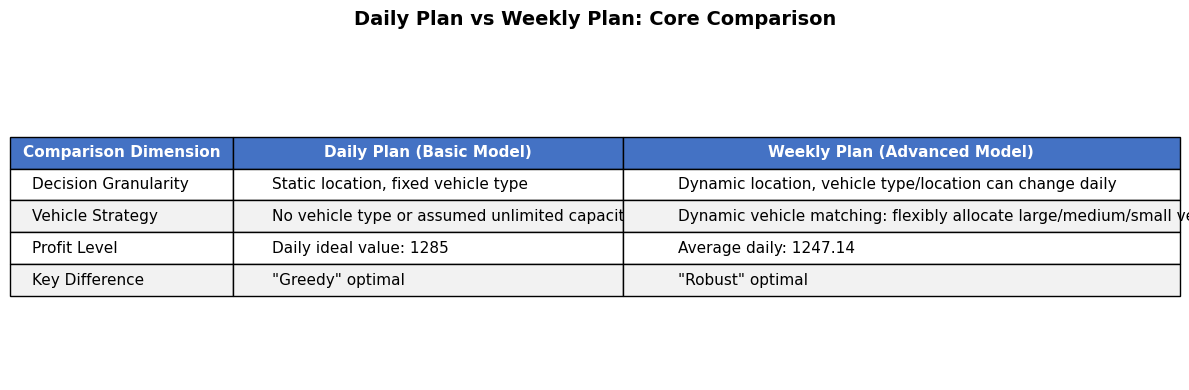

In [1]:
import matplotlib.pyplot as plt

# Define table data in English
columns = ['Comparison Dimension', 'Daily Plan (Basic Model)', 'Weekly Plan (Advanced Model)']
data = [
    ['Decision Granularity', 'Static location, fixed vehicle type', 'Dynamic location, vehicle type/location can change daily'],
    ['Vehicle Strategy', 'No vehicle type or assumed unlimited capacity', 'Dynamic vehicle matching: flexibly allocate large/medium/small vehicles based on next-day demand forecast'],
    ['Profit Level', 'Daily ideal value: 1285', 'Average daily: 1247.14'],
    ['Key Difference', '"Greedy" optimal', '"Robust" optimal']
]

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')  # Hide axes

# Draw table
table = ax.table(
    cellText=data,
    colLabels=columns,
    loc='center',
    cellLoc='left',
    colWidths=[0.2, 0.35, 0.5]  # Adjust column width ratios
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)  # Scale table, increase row height

# Format header row
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_facecolor('#4472C4')
        cell.set_text_props(weight='bold', color='white')
    else:
        cell.set_facecolor('#F2F2F2' if row % 2 == 0 else 'white')

plt.title('Daily Plan vs Weekly Plan: Core Comparison', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

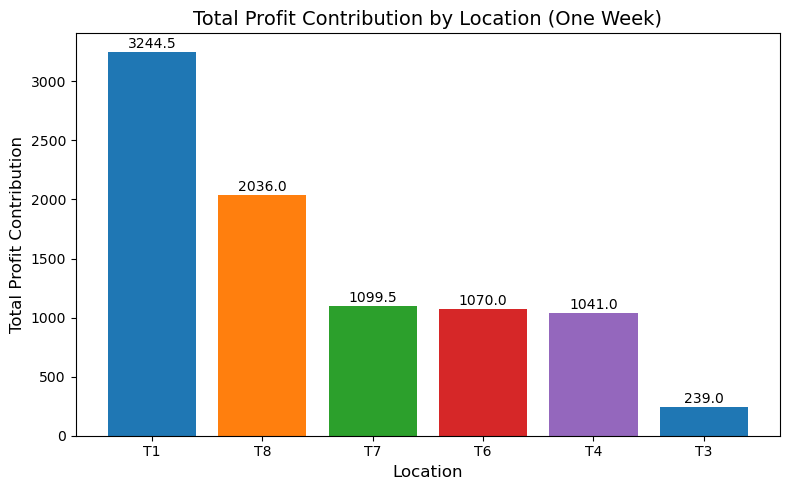

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Input data
data = {
    'Day': ['Day_1', 'Day_1', 'Day_1', 'Day_2', 'Day_2', 'Day_2', 'Day_2', 
            'Day_3', 'Day_3', 'Day_3', 'Day_3', 'Day_4', 'Day_4', 'Day_4', 
            'Day_5', 'Day_5', 'Day_5', 'Day_6', 'Day_6', 'Day_6', 'Day_6', 
            'Day_7', 'Day_7', 'Day_7'],
    'Location': ['T1', 'T4', 'T8', 'T1', 'T3', 'T6', 'T7', 'T1', 'T6', 'T7', 'T8', 
                 'T1', 'T6', 'T7', 'T1', 'T4', 'T8', 'T1', 'T4', 'T6', 'T8', 
                 'T1', 'T4', 'T8'],
    'Truck_Type': ['Large', 'Small', 'Small', 'Medium', 'Small', 'Small', 'Small', 
                   'Medium', 'Small', 'Small', 'Small', 'Medium', 'Small', 'Medium', 
                   'Large', 'Small', 'Medium', 'Small', 'Small', 'Small', 'Medium', 
                   'Large', 'Small', 'Medium'],
    'Customers_Served': [4, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 4, 2, 4, 3, 3, 4, 2, 3, 1, 4, 3, 3, 4],
    'Daily_Profit_Contribution': [636.0, 215.0, 316.5, 436.5, 239.0, 254.5, 319.0, 
                                  353.5, 319.0, 286.0, 293.0, 483.0, 280.5, 494.5, 
                                  461.0, 280.5, 494.0, 304.0, 233.5, 216.0, 456.5, 
                                  570.5, 312.0, 476.0]
}
df = pd.DataFrame(data)

# Sum total profit by location
total_profit_by_location = df.groupby('Location')['Daily_Profit_Contribution'].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(total_profit_by_location.index, total_profit_by_location.values, 
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:len(total_profit_by_location)])

# Annotate total profit values above bars
for bar, value in zip(bars, total_profit_by_location.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
             f'{value:.1f}', ha='center', va='bottom', fontsize=10)

# Set chart labels and title
plt.xlabel('Location', fontsize=12)
plt.ylabel('Total Profit Contribution', fontsize=12)
plt.title('Total Profit Contribution by Location (One Week)', fontsize=14)

plt.tight_layout()
plt.show()